Using device: cuda
--- Loading Data ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

...

/tmp/ipython-input-682655989.py:140: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `PolyLossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



--- Starting Training (PolyLoss, Epsilon=1.0) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.320500,1.033159,0.616883,0.621812
2,0.880700,0.980143,0.704545,0.685452
3,0.514300,1.117482,0.675325,0.643857
4,0.346600,1.274596,0.746753,0.690562
5,0.266200,1.545164,0.759740,0.712262
6,0.130200,2.001117,0.743506,0.684683
7,0.067800,2.065244,0.750000,0.690748
8,0.088100,2.289279,0.753247,0.691728
9,0.015000,2.258996,0.756494,0.704927
10,0.025200,2.369183,0.743506,0.690895



--- Final Evaluation ---



Classification Report:
                 precision    recall  f1-score   support

    Clear Reply     0.6023    0.6709    0.6347        79
     Ambivalent     0.8497    0.7961    0.8221       206
Clear Non-Reply     0.6296    0.7391    0.6800        23

       accuracy                         0.7597       308
      macro avg     0.6939    0.7354    0.7123       308
   weighted avg     0.7698    0.7597    0.7634       308



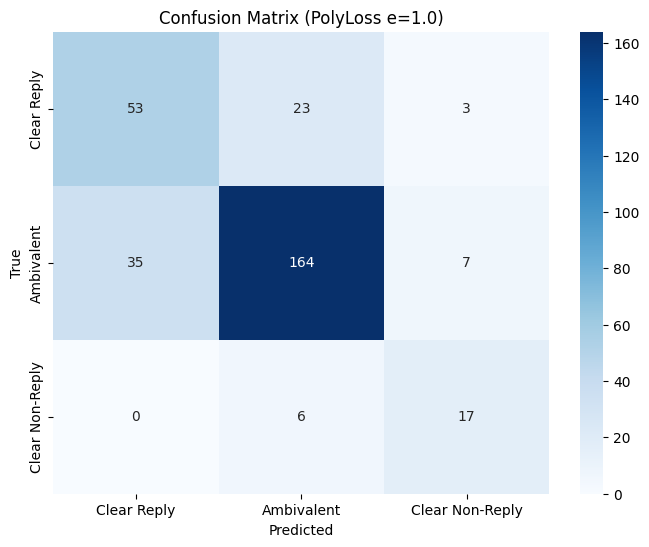


Model saved successfully.


In [1]:
# ==========================================
# 1. INSTALL LIBRARIES
# ==========================================
!pip install -q transformers datasets torch scikit-learn accelerate sentencepiece seaborn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EvalPrediction
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. CONFIGURATION
# ==========================================
MODEL_ID = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

# High context length for interview answers
MAX_LENGTH = 2048

# Training Hyperparameters
BATCH_SIZE = 2
GRAD_ACCUMULATION = 8   # Effective batch size = 16
LEARNING_RATE = 1e-5
EPOCHS = 10

# PolyLoss Hyperparameter
# 1.0 is standard. Increase to 2.0 if it still ignores minority.
POLY_EPSILON = 1.0

# Labels
LABEL_MAP = {'Clear Reply': 0, 'Ambivalent': 1, 'Clear Non-Reply': 2}
ID2LABEL = {0: 'Clear Reply', 1: 'Ambivalent', 2: 'Clear Non-Reply'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = len(LABEL_MAP)

# ==========================================
# 3. DATA PREPARATION & WEIGHTS
# ==========================================
print("--- Loading Data ---")
dataset = load_dataset("ailsntua/QEvasion")

# --- Calculate Class Weights ---
def get_class_weights(dataset, label_map, device):
    train_labels = [label_map[label] for label in dataset["train"]["clarity_label"]]
    label_counts = Counter(train_labels)
    total_samples = len(train_labels)
    num_classes = len(label_map)

    class_weights = []
    for i in range(num_classes):
        count = label_counts.get(i, 0)
        weight = total_samples / (num_classes * count) if count > 0 else 0.0
        class_weights.append(weight)

    return torch.tensor(class_weights, dtype=torch.float32).to(device)

class_weights = get_class_weights(dataset, LABEL_MAP, device)
print(f"Calculated Class Weights: {class_weights}")

# --- Tokenization ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.model_max_length = MAX_LENGTH

def preprocess_function(examples):
    hypotheses = [f"The speaker explicitly answers the question: {q}" for q in examples['question']]
    premises = examples['interview_answer']

    model_inputs = tokenizer(
        premises,
        hypotheses,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False
    )

    if 'clarity_label' in examples:
        model_inputs["labels"] = [LABEL_MAP[label] for label in examples['clarity_label']]

    return model_inputs

encoded_dataset = dataset.map(preprocess_function, batched=True)

# ==========================================
# 4. POLY-1 LOSS FUNCTION (THE SOLUTION)
# ==========================================
class Poly1Loss(nn.Module):
    def __init__(self, num_classes, epsilon=1.0, weight=None, reduction='mean'):
        super(Poly1Loss, self).__init__()
        self.num_classes = num_classes
        self.epsilon = epsilon
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits, labels):
        # 1. Standard Cross Entropy (Weighted)
        # We use reduction='none' so we can add the poly term element-wise first
        if self.weight is not None and self.weight.device != logits.device:
            self.weight = self.weight.to(logits.device)

        ce_loss = F.cross_entropy(logits, labels, weight=self.weight, reduction='none')

        # 2. Get probability of the *true* class (pt)
        # Softmax to get probabilities
        probs = F.softmax(logits, dim=1)
        # Gather the probability specifically for the target label
        pt = probs.gather(1, labels.unsqueeze(1)).squeeze(1)

        # 3. Poly1 Formula: Loss = CE + epsilon * (1 - pt)
        poly_loss = ce_loss + self.epsilon * (1 - pt)

        if self.reduction == 'mean':
            return poly_loss.mean()
        elif self.reduction == 'sum':
            return poly_loss.sum()
        else:
            return poly_loss

# ==========================================
# 5. CUSTOM TRAINER
# ==========================================
class PolyLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, epsilon=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        # Initialize Poly1Loss with class weights
        self.loss_fct = Poly1Loss(
            num_classes=self.model.config.num_labels,
            epsilon=epsilon,
            weight=class_weights
        )

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Calculate PolyLoss
        loss = self.loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ==========================================
# 6. MODEL SETUP & METRICS
# ==========================================
config = AutoConfig.from_pretrained(MODEL_ID)
config.max_position_embeddings = MAX_LENGTH
config.num_labels = NUM_LABELS
config.id2label = ID2LABEL
config.label2id = LABEL2ID
config.use_cache = False

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    config=config,
    ignore_mismatched_sizes=True
)
model.to(device)

def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# ==========================================
# 7. TRAINING LOOP
# ==========================================
training_args = TrainingArguments(
    output_dir="./deberta_nli_polyloss",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=25,
    report_to="none"
)

trainer = PolyLossTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights, # Pass weights for the CE component
    epsilon=POLY_EPSILON         # Pass epsilon for the Poly component
)

print(f"\n--- Starting Training (PolyLoss, Epsilon={POLY_EPSILON}) ---")
trainer.train()

# ==========================================
# 8. FINAL EVALUATION & VISUALIZATION
# ==========================================
print("\n--- Final Evaluation ---")
predictions_output = trainer.predict(encoded_dataset["test"])
y_preds = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# Classification Report
target_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]
print("\nClassification Report:")
print(classification_report(y_true, y_preds, target_names=target_names, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (PolyLoss e={POLY_EPSILON})')
plt.show()

# Save Model
trainer.save_model("./Final_PolyLoss_Model")
tokenizer.save_pretrained("./Final_PolyLoss_Model")
print("\nModel saved successfully.")